<a href="https://colab.research.google.com/github/hmurtaza720/Data-Science-Projects/blob/main/Credit_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: Credit Risk Prediction — Loan Default

## Introduction & Problem Statement
Financial institutions need to assess whether a loan applicant is likely to **default** (fail to repay) on their loan. Predicting credit risk helps banks minimize financial losses.

In this task, we build a **binary classification model** to predict loan default using applicant data such as income, loan amount, and education.

**Target Variable:** `Loan_Status` — Y (approved/no default) or N (rejected/default risk)

## Dataset
> **Loan Prediction Dataset** from Kaggle
>
> **Download Link:** https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
>


## Objectives
- Handle missing data
- Visualize key features
- Train Logistic Regression and Decision Tree classifiers
- Evaluate using accuracy and confusion matrix

## Step 1: Install & Import Libraries

In [1]:
# Install required libraries (uncomment if needed)
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load the Dataset



In [3]:

from google.colab import files
uploaded = files.upload()
df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')
print('Dataset loaded from upload!')
df.head()

Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i (1).csv
Dataset loaded from upload!


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Step 3: Dataset Understanding & Description

In [4]:
# Shape and columns
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Shape: (614, 13)
Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [5]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
# Statistical summary
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
# Check target variable distribution
print('Loan Status Distribution:')
print(df['Loan_Status'].value_counts())
print(f'\nApproval Rate: {(df["Loan_Status"]=="Y").mean()*100:.1f}%')

Loan Status Distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Approval Rate: 68.7%


## Step 4: Data Cleaning & Handling Missing Values

In [8]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing Values Summary:')
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values Summary:
                  Missing Count  Missing %
Gender                       13       2.12
Married                       3       0.49
Dependents                   15       2.44
Self_Employed                32       5.21
LoanAmount                   22       3.58
Loan_Amount_Term             14       2.28
Credit_History               50       8.14


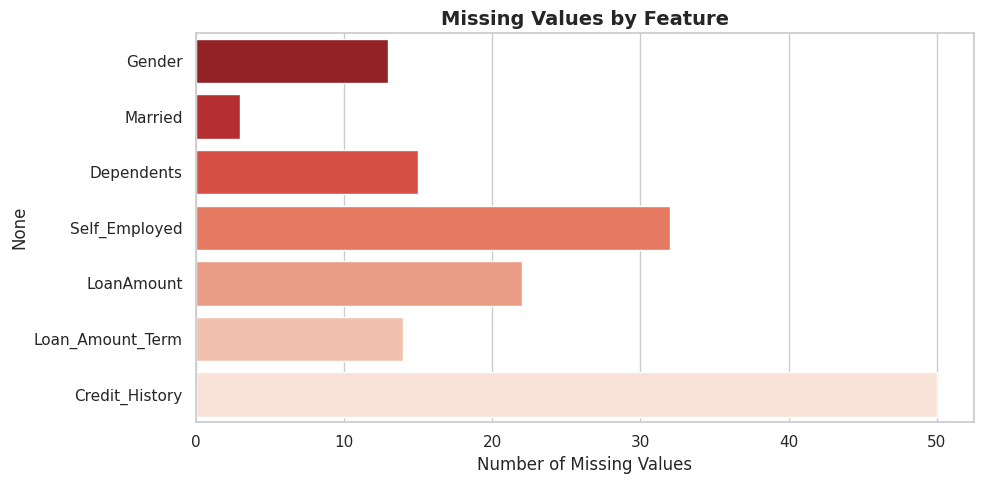

In [9]:
# Visualize missing values
plt.figure(figsize=(10, 5))
missing_cols = missing[missing > 0]
sns.barplot(x=missing_cols.values, y=missing_cols.index, palette='Reds_r')
plt.title('Missing Values by Feature', fontsize=14, fontweight='bold')
plt.xlabel('Number of Missing Values')
plt.tight_layout()
plt.show()

In [10]:
# Fill missing values
# Categorical columns: fill with mode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']
for col in categorical_cols:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical column: fill with median
if 'LoanAmount' in df.columns:
    df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

print('Missing values after cleaning:')
print(df.isnull().sum().sum(), 'total missing values remaining')

Missing values after cleaning:
0 total missing values remaining


## Step 5: Exploratory Data Analysis (EDA) with Graphs

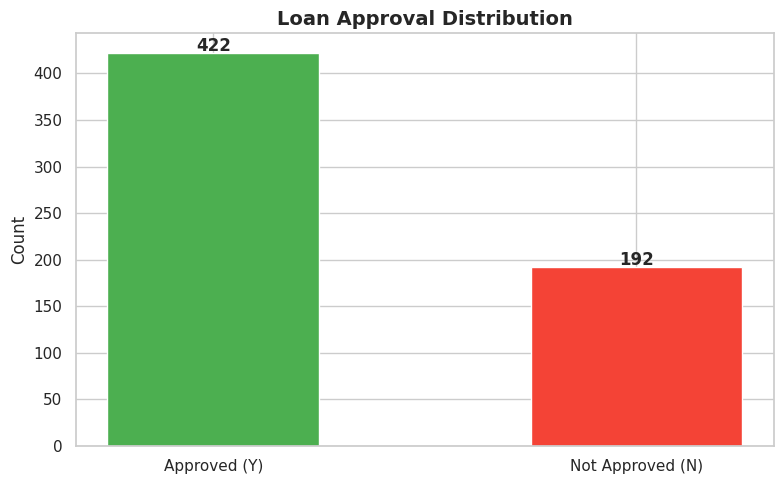

In [11]:
# Loan Status distribution (target variable)
plt.figure(figsize=(8, 5))
loan_counts = df['Loan_Status'].value_counts()
colors = ['#4CAF50', '#F44336']
plt.bar(['Approved (Y)', 'Not Approved (N)'], loan_counts.values, color=colors, edgecolor='white', width=0.5)
plt.title('Loan Approval Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')
for i, v in enumerate(loan_counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

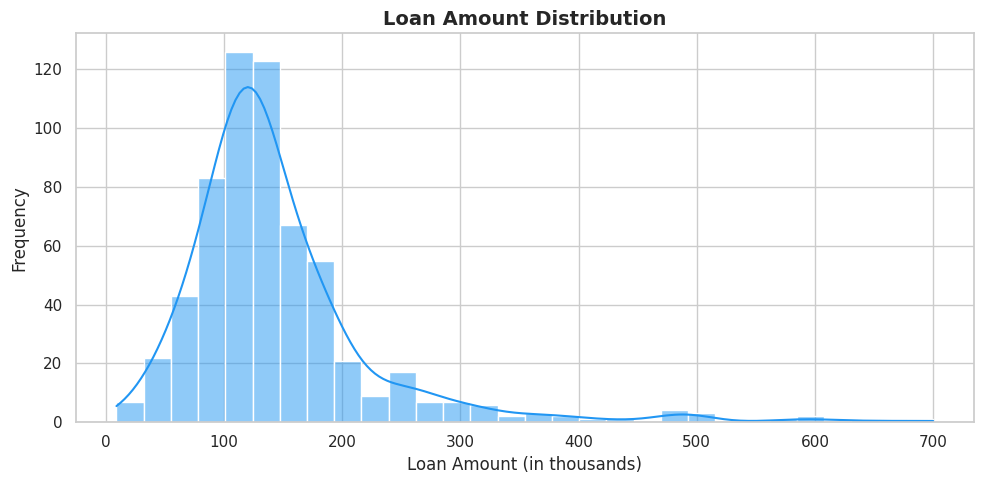

In [12]:
# Loan Amount distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['LoanAmount'], bins=30, kde=True, color='#2196F3')
plt.title('Loan Amount Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Loan Amount (in thousands)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

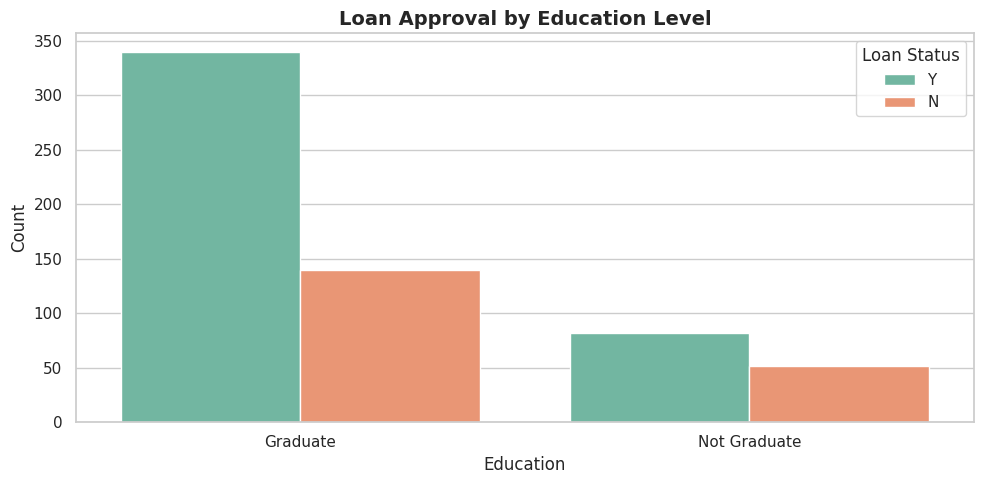

In [13]:
# Education vs Loan Status
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Education', hue='Loan_Status', palette='Set2')
plt.title('Loan Approval by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

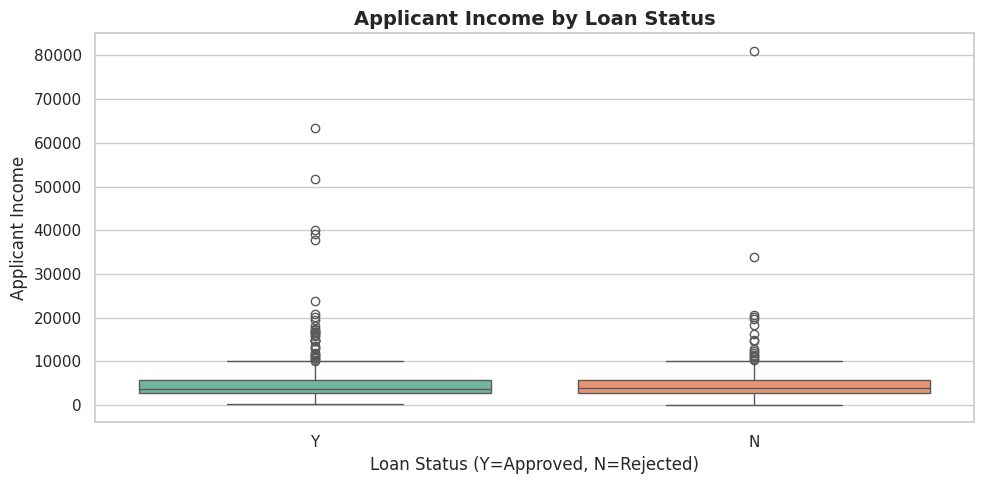

In [14]:
# Applicant Income distribution by Loan Status
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome', palette='Set2')
plt.title('Applicant Income by Loan Status', fontsize=14, fontweight='bold')
plt.xlabel('Loan Status (Y=Approved, N=Rejected)')
plt.ylabel('Applicant Income')
plt.tight_layout()
plt.show()

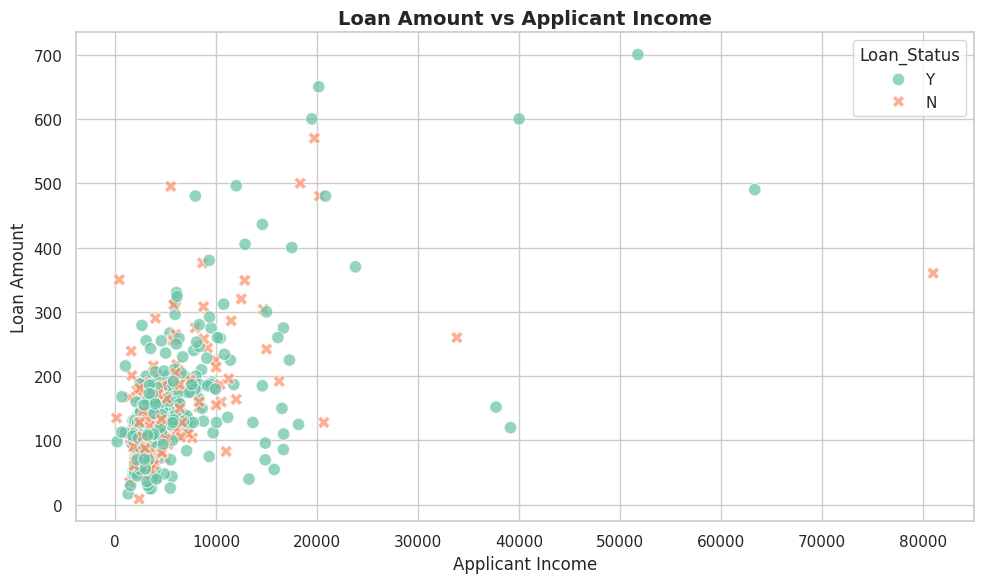

In [15]:
# Loan Amount vs Applicant Income scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount',
                hue='Loan_Status', style='Loan_Status', alpha=0.7, s=80)
plt.title('Loan Amount vs Applicant Income', fontsize=14, fontweight='bold')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.tight_layout()
plt.show()

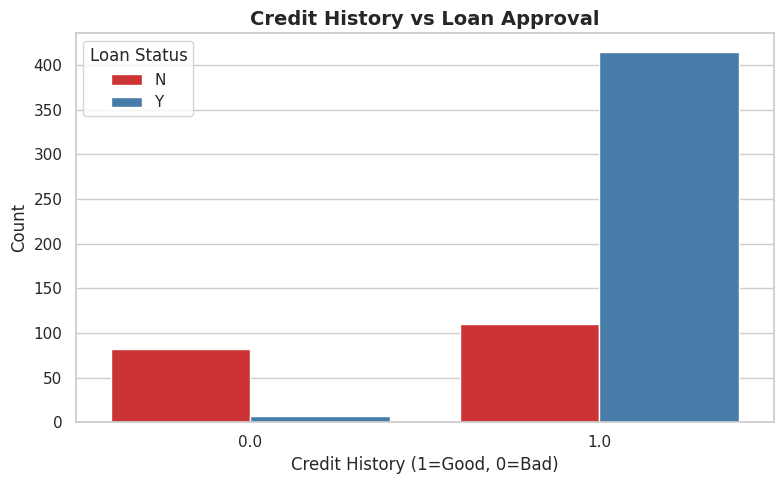

In [16]:
# Credit History vs Loan Status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Credit_History', hue='Loan_Status', palette='Set1')
plt.title('Credit History vs Loan Approval', fontsize=14, fontweight='bold')
plt.xlabel('Credit History (1=Good, 0=Bad)')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

## Step 6: Data Preparation for Modeling

In [17]:
# Drop Loan_ID (not a feature)
if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

# Encode all categorical columns using Label Encoding
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Encoding columns:', cat_cols)

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('All categorical columns encoded.')
df.head()

Encoding columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
All categorical columns encoded.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [18]:
# Define features (X) and target (y)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 491
Testing samples:  123


## Step 7: Model Training & Testing

### 7.1 Logistic Regression

In [19]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Accuracy
lr_acc = accuracy_score(y_test, lr_pred)
print(f'Logistic Regression Accuracy: {lr_acc * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 86.18%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



<Figure size 700x500 with 0 Axes>

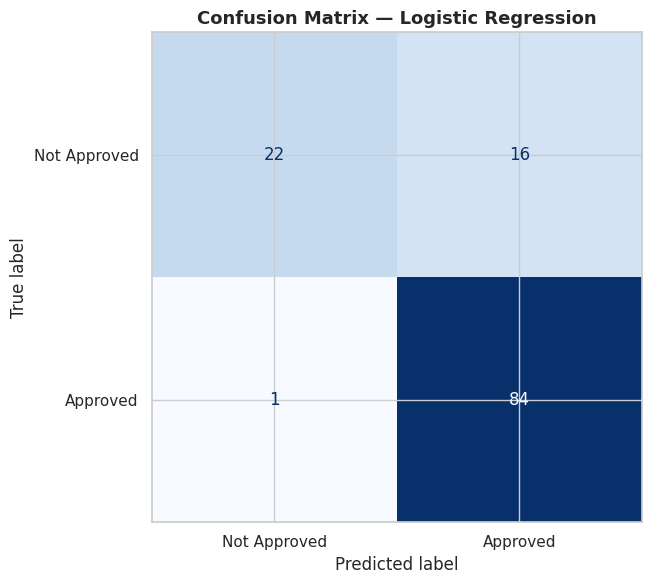

In [20]:
# Confusion Matrix - Logistic Regression
plt.figure(figsize=(7, 5))
cm_lr = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not Approved', 'Approved'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Decision Tree Classifier

In [21]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Accuracy
dt_acc = accuracy_score(y_test, dt_pred)
print(f'Decision Tree Accuracy: {dt_acc * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 82.11%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.55      0.66        38
           1       0.82      0.94      0.88        85

    accuracy                           0.82       123
   macro avg       0.82      0.75      0.77       123
weighted avg       0.82      0.82      0.81       123



<Figure size 700x500 with 0 Axes>

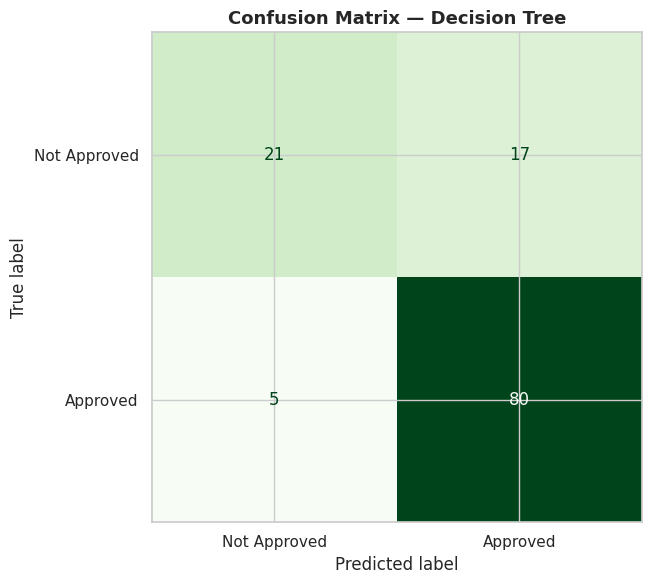

In [22]:
# Confusion Matrix - Decision Tree
plt.figure(figsize=(7, 5))
cm_dt = confusion_matrix(y_test, dt_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Not Approved', 'Approved'])
disp2.plot(cmap='Greens', colorbar=False)
plt.title('Confusion Matrix — Decision Tree', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: Evaluation Metrics — Model Comparison

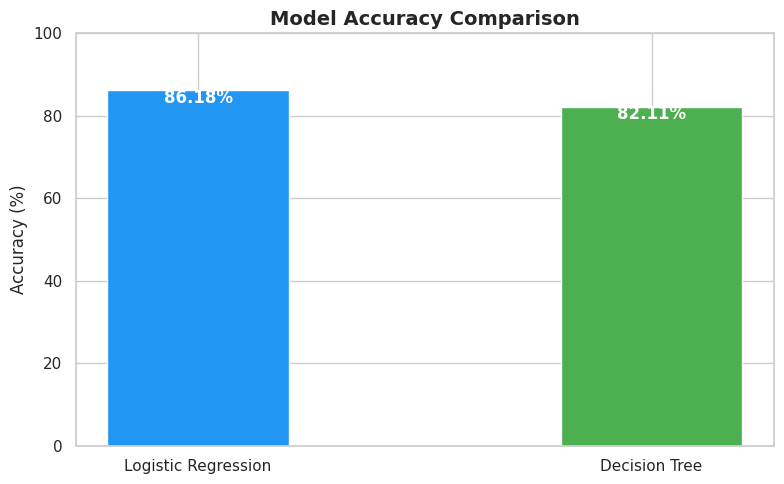


Best Model: Logistic Regression (86.18%)


In [23]:
# Side-by-side accuracy comparison
models = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_acc * 100, dt_acc * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#2196F3', '#4CAF50'], width=0.4, edgecolor='white')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
             f'{acc:.2f}%', ha='center', color='white', fontweight='bold', fontsize=12)
plt.ylim(0, 100)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()

print(f'\nBest Model: {models[np.argmax(accuracies)]} ({max(accuracies):.2f}%)')

## Step 9: Conclusion & Key Insights

1. **Credit History is the most important factor** — applicants with good credit history (1) have a significantly higher approval rate.

2. **Missing Data Handling** — We used mode imputation for categorical columns and median for loan amount, which is appropriate for skewed distributions.

3. **Model Performance** — Both Logistic Regression and Decision Tree achieved reasonable accuracy. Logistic Regression is preferred here due to its interpretability and stability.

4. **Income vs Loan Amount** — Higher income applicants tend to request and receive larger loan amounts.

5. **Business Impact** — The model can help banks automate and speed up the loan approval process while reducing default risk.